# Class Overlap & Resampling Readiness

# 00. Import 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

OUTPUT_REPORTS = '../../../outputs/reports/'
OUTPUT_FIGURES = '../../../outputs/figures/resampling_diagnostics/'

import os
os.makedirs(OUTPUT_REPORTS, exist_ok=True)
os.makedirs(OUTPUT_FIGURES, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


# 01. Load Data

In [2]:
df = pd.read_csv('../../../data/processed/daily_eda_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Unique users: {df["user_id"].nunique()}')
print()
print('stress_level distribution:')
vc = df['stress_level'].value_counts()
for lvl, cnt in vc.items():
    pct = cnt / len(df) * 100
    print(f'  {lvl:8s}: {cnt:5d} ({pct:.1f}%)')

Shape: (26579, 21)
Unique users: 300

stress_level distribution:
  Medium  : 23256 (87.5%)
  High    :  2583 (9.7%)
  Low     :   740 (2.8%)


# 02. Feature Set Scenarios

In [3]:
# Sesuai Scenario A, B, C, D

ORIGINAL_FEATURES = [
    'sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours',
    'physical_activity_minutes', 'caffeine_intake_mg', 'mood_score',
    'fatigue_level', 'assignment_load', 'deadline_pressure',
    'social_interaction_score', 'financial_worry_score', 'health_condition_score'
]

CORE_FEATURES = [
    'sleep_hours', 'physical_activity_minutes', 'study_hours',
    'screen_time_hours', 'assignment_load', 'deadline_pressure',
    'fatigue_level', 'mood_score'
]

TARGET = 'stress_level'
GROUP_COL = 'user_id'

# Build engineered features inline
def build_engineered_features(df):
    df = df.copy()
    df['social_media_ratio']      = df['social_media_hours'] / (df['screen_time_hours'] + 1e-9)
    df['study_screen_balance']    = df['study_hours'] / (df['screen_time_hours'] + 1)
    df['academic_pressure_index'] = (df['assignment_load'] + df['deadline_pressure']) / 2
    df['recovery_index']          = (df['sleep_hours'] * df['mood_score']) / (df['fatigue_level'] + 1)
    df['digital_pressure_index']  = df['screen_time_hours'] + df['social_media_hours']
    df['emotional_pressure_index']= df['fatigue_level'] + (10 - df['mood_score'])

    df['sleep_category'] = pd.cut(
        df['sleep_hours'],
        bins=[0, 6, 8, 99], labels=['kurang', 'cukup', 'lebih']
    ).astype(str)
    df['activity_level'] = pd.cut(
        df['physical_activity_minutes'],
        bins=[0, 15, 45, 9999], labels=['rendah', 'sedang', 'tinggi']
    ).astype(str)
    df['caffeine_category'] = pd.cut(
        df['caffeine_intake_mg'],
        bins=[0, 200, 350, 99999], labels=['normal', 'tinggi', 'sangat_tinggi']
    ).astype(str)
    return df

df = build_engineered_features(df)

ENGINEERED_NUMERIC = [
    'social_media_ratio', 'study_screen_balance', 'academic_pressure_index',
    'recovery_index', 'digital_pressure_index', 'emotional_pressure_index'
]
# Kolom kategorikal (sleep_category, activity_level, caffeine_category) 
# disimpan untuk insight/dashboard, tidak dimasukkan ke feature space numerik
# karena SMOTE bekerja di ruang numerik

SCENARIO_A = ORIGINAL_FEATURES                   
SCENARIO_B = CORE_FEATURES                          
SCENARIO_C = ORIGINAL_FEATURES + ENGINEERED_NUMERIC 
SCENARIO_D = None  

print('Feature sets defined.')
print(f'  A (Full original)        : {len(SCENARIO_A)} features')
print(f'  B (Core original)        : {len(SCENARIO_B)} features')
print(f'  C (Original + Engineered): {len(SCENARIO_C)} features')
print(f'  D (Core + Selected Eng.) : ditentukan setelah multicollinearity check')

Feature sets defined.
  A (Full original)        : 13 features
  B (Core original)        : 8 features
  C (Original + Engineered): 19 features
  D (Core + Selected Eng.) : ditentukan setelah multicollinearity check


# 03. Split Strategy 

In [4]:
y = df[TARGET]
groups = df[GROUP_COL]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

print('=== Group-Aware Split (GroupShuffleSplit by user_id) ===')
print(f'Train: {len(df_train):5d} rows | {df_train[GROUP_COL].nunique()} users')
print(f'Test : {len(df_test):5d} rows | {df_test[GROUP_COL].nunique()} users')
print()
print('Distribusi stress_level — Train:')
tc = df_train[TARGET].value_counts()
for lvl, cnt in tc.items():
    print(f'  {lvl:8s}: {cnt:5d} ({cnt/len(df_train)*100:.1f}%)')
print()
print('Distribusi stress_level — Test:')
ec = df_test[TARGET].value_counts()
for lvl, cnt in ec.items():
    print(f'  {lvl:8s}: {cnt:5d} ({cnt/len(df_test)*100:.1f}%)')

# Simpan summary split
split_summary = pd.DataFrame({
    'split'       : ['train', 'test'],
    'n_rows'      : [len(df_train), len(df_test)],
    'n_users'     : [df_train[GROUP_COL].nunique(), df_test[GROUP_COL].nunique()],
    'n_Low'       : [tc.get('Low', 0), ec.get('Low', 0)],
    'n_Medium'    : [tc.get('Medium', 0), ec.get('Medium', 0)],
    'n_High'      : [tc.get('High', 0), ec.get('High', 0)],
    'pct_Low'     : [tc.get('Low',0)/len(df_train)*100, ec.get('Low',0)/len(df_test)*100],
    'pct_Medium'  : [tc.get('Medium',0)/len(df_train)*100, ec.get('Medium',0)/len(df_test)*100],
    'pct_High'    : [tc.get('High',0)/len(df_train)*100, ec.get('High',0)/len(df_test)*100],
    'strategy'    : ['GroupShuffleSplit(user_id)', 'GroupShuffleSplit(user_id)'],
})
split_summary.to_csv(OUTPUT_REPORTS + 'split_strategy_summary.csv', index=False)
print()
print('Saved: split_strategy_summary.csv')

=== Group-Aware Split (GroupShuffleSplit by user_id) ===
Train: 21256 rows | 240 users
Test :  5323 rows | 60 users

Distribusi stress_level — Train:
  Medium  : 18596 (87.5%)
  High    :  2033 (9.6%)
  Low     :   627 (2.9%)

Distribusi stress_level — Test:
  Medium  :  4660 (87.5%)
  High    :   550 (10.3%)
  Low     :   113 (2.1%)

Saved: split_strategy_summary.csv


# 04. Multicollinearity Check

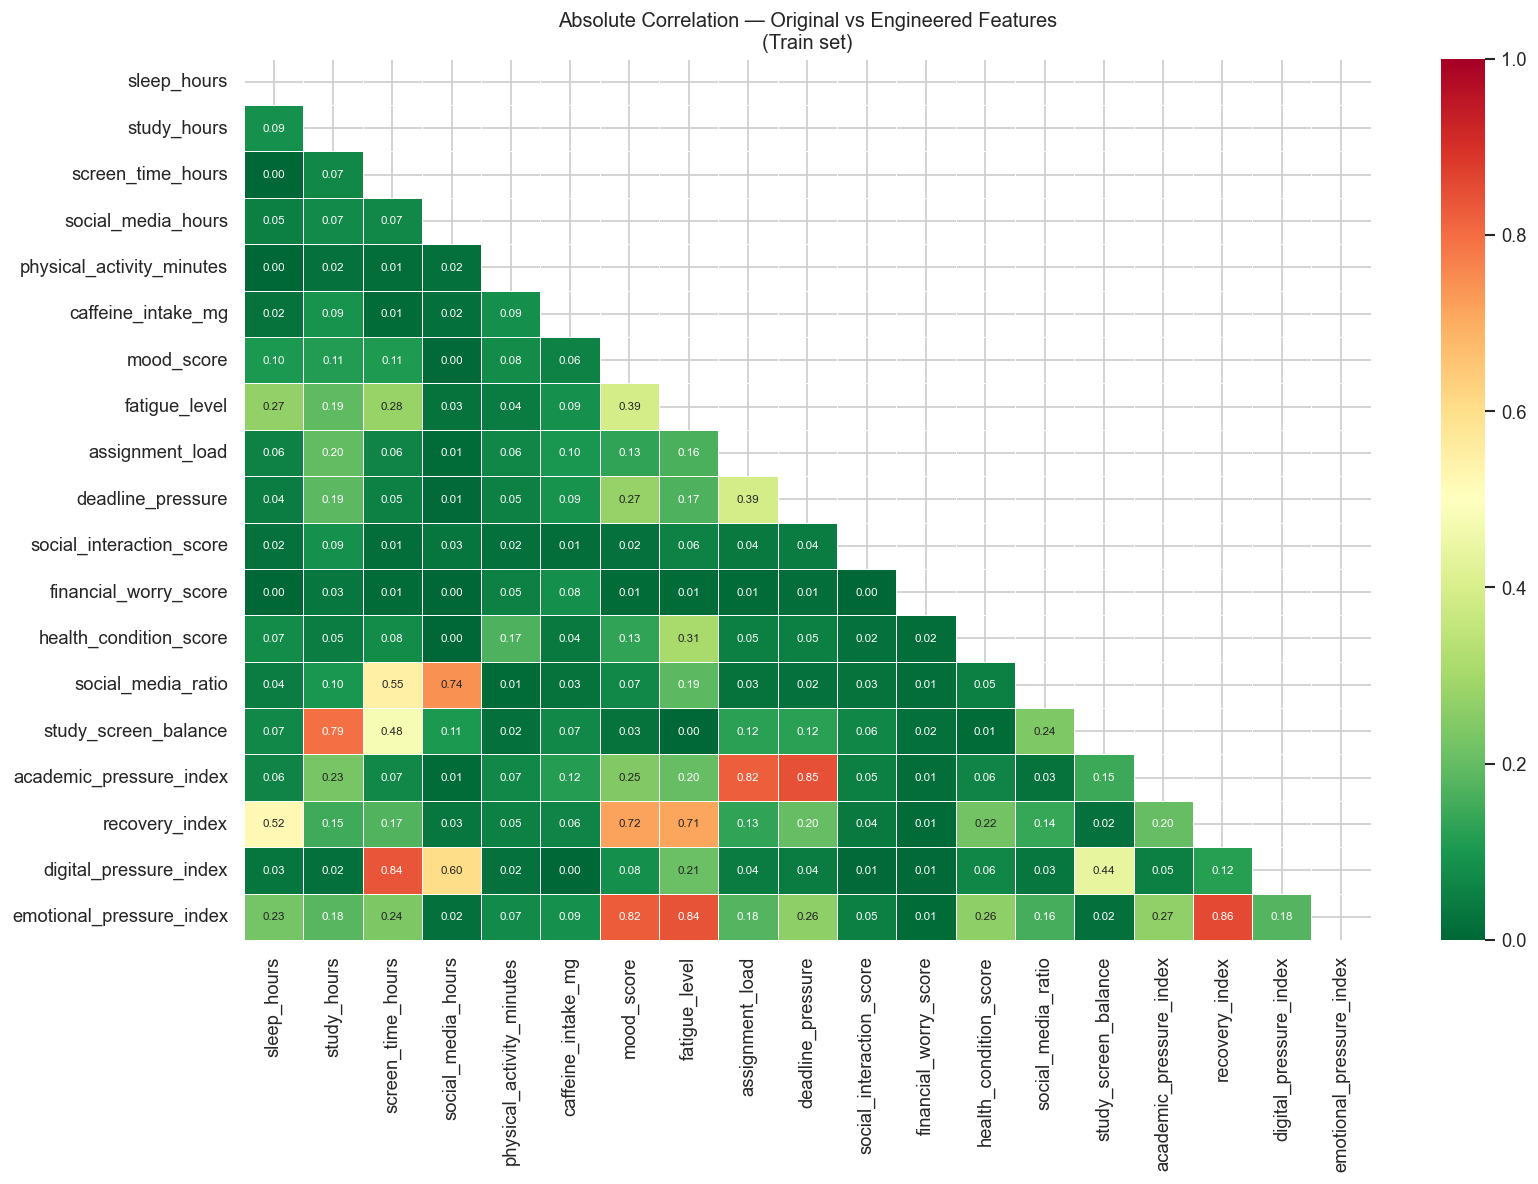

In [5]:
#Engineered vs Original

corr_matrix = df_train[ORIGINAL_FEATURES + ENGINEERED_NUMERIC].corr().abs()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Absolute Correlation — Original vs Engineered Features\n(Train set)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '01_multicollinearity_heatmap.png', bbox_inches='tight')
plt.show()

In [6]:
# Cek pasangan dengan korelasi sangat tinggi
HIGH_CORR_THRESHOLD = 0.85

pairs = []
for i, f1 in enumerate(ORIGINAL_FEATURES + ENGINEERED_NUMERIC):
    for j, f2 in enumerate(ORIGINAL_FEATURES + ENGINEERED_NUMERIC):
        if j <= i:
            continue
        r = corr_matrix.loc[f1, f2]
        if r > HIGH_CORR_THRESHOLD:
            is_eng_f1 = f1 in ENGINEERED_NUMERIC
            is_eng_f2 = f2 in ENGINEERED_NUMERIC
            pair_type = (
                'eng-eng' if is_eng_f1 and is_eng_f2 else
                'eng-orig' if (is_eng_f1 or is_eng_f2) else
                'orig-orig'
            )
            pairs.append({'feature_1': f1, 'feature_2': f2, 'correlation': round(r, 4), 'pair_type': pair_type})

if pairs:
    print(f'Pasangan dengan korelasi > {HIGH_CORR_THRESHOLD}:')
    high_corr_df = pd.DataFrame(pairs).sort_values('correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print(f'Tidak ada pasangan dengan korelasi absolut > {HIGH_CORR_THRESHOLD}')
    high_corr_df = pd.DataFrame(columns=['feature_1','feature_2','correlation','pair_type'])

Pasangan dengan korelasi > 0.85:
     feature_1                feature_2  correlation pair_type
recovery_index emotional_pressure_index       0.8571   eng-eng


In [7]:
# Keputusan Scenario D berdasarkan multicollinearity check

flagged_engineered = set()
for _, row in high_corr_df.iterrows():
    if row['pair_type'] == 'eng-orig':
        # Buang engineered feature yang duplikat dengan original
        eng = row['feature_1'] if row['feature_1'] in ENGINEERED_NUMERIC else row['feature_2']
        flagged_engineered.add(eng)
    elif row['pair_type'] == 'eng-eng':
        # Dari pasangan eng-eng, buang yang lebih redundan terhadap original features
        f1, f2 = row['feature_1'], row['feature_2']
        corr_f1_orig = corr_matrix.loc[f1, ORIGINAL_FEATURES].max()
        corr_f2_orig = corr_matrix.loc[f2, ORIGINAL_FEATURES].max()
        more_redundant = f1 if corr_f1_orig >= corr_f2_orig else f2
        flagged_engineered.add(more_redundant)

SCENARIO_D = CORE_FEATURES + [f for f in ENGINEERED_NUMERIC if f not in flagged_engineered]

print('=== Scenario D (Core + Selected Engineered) ===')
print(f'Flagged (near-duplicate): {flagged_engineered if flagged_engineered else "tidak ada"}')
print(f'Features ({len(SCENARIO_D)}): {SCENARIO_D}')

=== Scenario D (Core + Selected Engineered) ===
Flagged (near-duplicate): {'emotional_pressure_index'}
Features (13): ['sleep_hours', 'physical_activity_minutes', 'study_hours', 'screen_time_hours', 'assignment_load', 'deadline_pressure', 'fatigue_level', 'mood_score', 'social_media_ratio', 'study_screen_balance', 'academic_pressure_index', 'recovery_index', 'digital_pressure_index']


# 05. Nearest-Neighbor Class Mixing (Overlap Diagnostic)

In [8]:
def compute_class_mixing(X, y, k=10):
    """
    Hitung nearest-neighbor class mixing per kelas.
    Return dict: {class_label: mixing_ratio}
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    mixing_per_class = {}
    for cls_idx, cls_name in enumerate(le.classes_):
        mask = y_enc == cls_idx
        sample_indices = np.where(mask)[0]
        
        mixing_ratios = []
        for i in sample_indices:
            neighbors = indices[i][1:]  # exclude self
            neighbor_labels = y_enc[neighbors]
            mixing = np.mean(neighbor_labels != cls_idx)
            mixing_ratios.append(mixing)
        
        mixing_per_class[cls_name] = np.mean(mixing_ratios)
    
    return mixing_per_class

def interpret_mixing(ratio):
    if ratio < 0.20:
        return 'Relatif aman — SMOTE masuk akal'
    elif ratio < 0.40:
        return 'Overlap sedang — bandingkan class_weight dan RandomOverSampler dulu'
    elif ratio < 0.60:
        return 'Overlap tinggi — uji BorderlineSMOTE atau SMOTE-Tomek'
    else:
        return 'Overlap berat — SMOTE polos TIDAK direkomendasikan'

scenarios = {
    'A_original_full'    : SCENARIO_A,
    'B_core_original'    : SCENARIO_B,
    'C_original_engineered': SCENARIO_C,
    'D_core_selected_eng': SCENARIO_D,
}

overlap_results = []

for scen_name, features in scenarios.items():
    X = df_train[features].values
    y_scen = df_train[TARGET]
    
    mixing = compute_class_mixing(X, y_scen, k=10)
    
    for cls, ratio in mixing.items():
        overlap_results.append({
            'scenario'    : scen_name,
            'class'       : cls,
            'mixing_ratio': round(ratio, 4),
            'mixing_pct'  : f'{ratio*100:.1f}%',
            'status'      : interpret_mixing(ratio),
        })
    
    print(f'\nScenario {scen_name}:')
    for cls, ratio in mixing.items():
        print(f'  {cls:8s}: {ratio*100:.1f}% — {interpret_mixing(ratio)}')

overlap_df = pd.DataFrame(overlap_results)
overlap_df.to_csv(OUTPUT_REPORTS + 'class_overlap_diagnostic_summary.csv', index=False)
print('\nSaved: class_overlap_diagnostic_summary.csv')


Scenario A_original_full:
  High    : 71.2% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Low     : 91.7% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Medium  : 6.7% — Relatif aman — SMOTE masuk akal

Scenario B_core_original:
  High    : 51.2% — Overlap tinggi — uji BorderlineSMOTE atau SMOTE-Tomek
  Low     : 81.9% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Medium  : 6.2% — Relatif aman — SMOTE masuk akal

Scenario C_original_engineered:
  High    : 65.4% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Low     : 87.9% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Medium  : 6.6% — Relatif aman — SMOTE masuk akal

Scenario D_core_selected_eng:
  High    : 50.1% — Overlap tinggi — uji BorderlineSMOTE atau SMOTE-Tomek
  Low     : 78.9% — Overlap berat — SMOTE polos TIDAK direkomendasikan
  Medium  : 6.4% — Relatif aman — SMOTE masuk akal

Saved: class_overlap_diagnostic_summary.csv


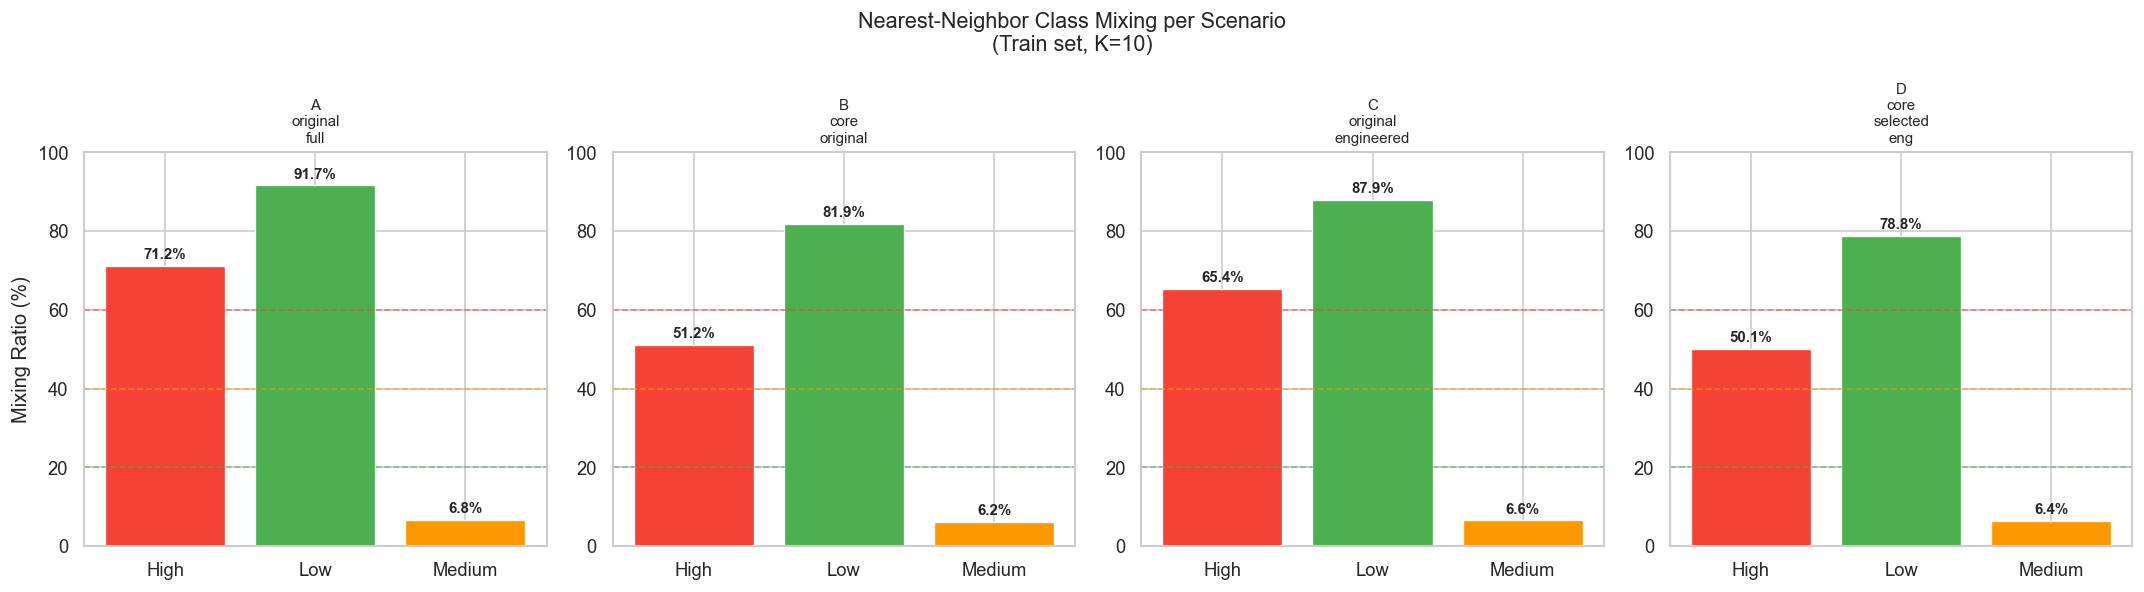

In [9]:
# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('Nearest-Neighbor Class Mixing per Scenario\n(Train set, K=10)', fontsize=13)

CLASS_COLORS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
THRESHOLD_COLORS = {0.20: '#4CAF50', 0.40: '#FF9800', 0.60: '#F44336'}

for ax, (scen_name, features) in zip(axes, scenarios.items()):
    scen_data = overlap_df[overlap_df['scenario'] == scen_name].copy()
    
    bars = ax.bar(
        scen_data['class'],
        scen_data['mixing_ratio'] * 100,
        color=[CLASS_COLORS[c] for c in scen_data['class']],
        edgecolor='white', linewidth=0.8
    )
    
    # Threshold lines
    for thresh, color in THRESHOLD_COLORS.items():
        ax.axhline(thresh * 100, color=color, linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_title(scen_name.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('Mixing Ratio (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    
    for bar, (_, row) in zip(bars, scen_data.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{row["mixing_ratio"]*100:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '02_class_mixing_per_scenario.png', bbox_inches='tight')
plt.show()

# 06. PCA Visualization - Class Separability

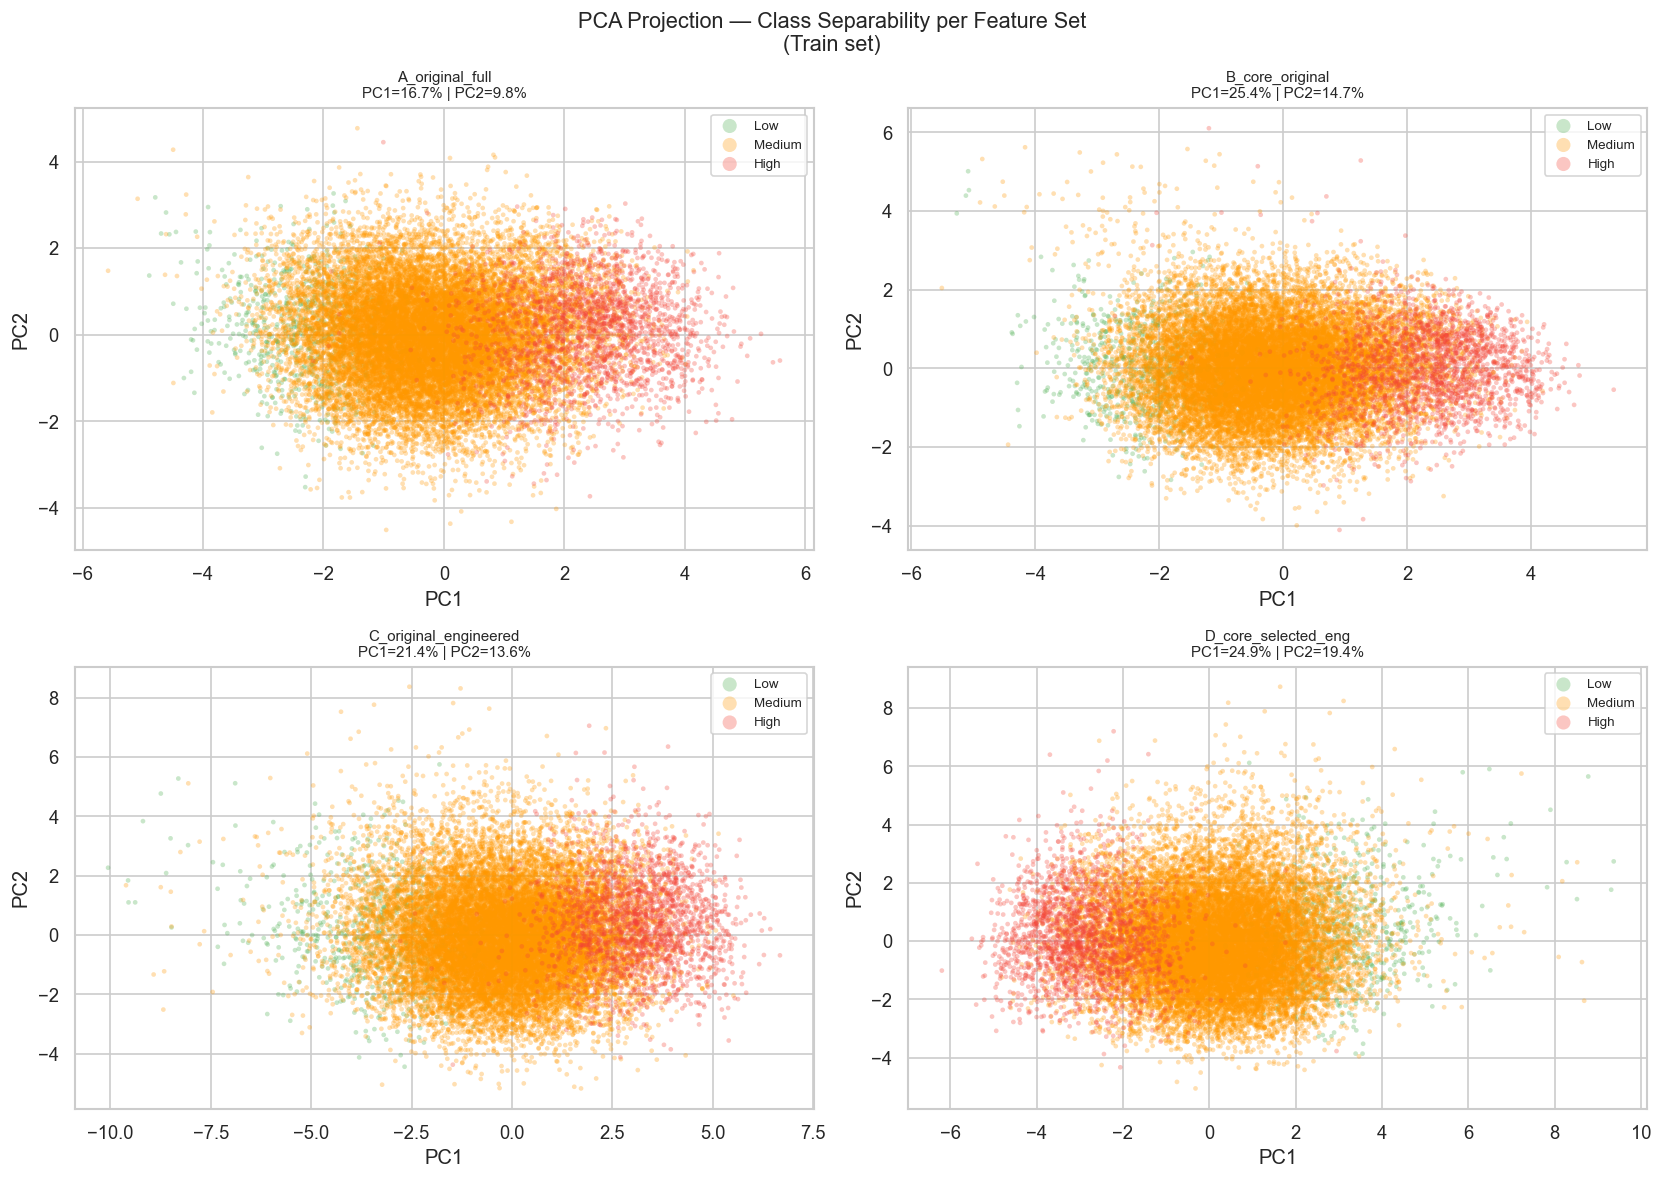

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PCA Projection — Class Separability per Feature Set\n(Train set)', fontsize=13)

CLASS_PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
axes_flat = axes.flatten()

for ax, (scen_name, features) in zip(axes_flat, scenarios.items()):
    X_raw = df_train[features].values
    y_raw = df_train[TARGET]
    
    X_scaled = StandardScaler().fit_transform(X_raw)
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    var_explained = pca.explained_variance_ratio_ * 100
    
    for cls in ['Low', 'Medium', 'High']:
        mask = y_raw == cls
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=CLASS_PALETTE[cls], label=cls,
            alpha=0.3, s=8, edgecolors='none'
        )
    
    ax.set_title(
        f'{scen_name}\nPC1={var_explained[0]:.1f}% | PC2={var_explained[1]:.1f}%',
        fontsize=9
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '03_pca_class_separability.png', bbox_inches='tight')
plt.show()

# 07. Baseline Model without Resampling

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
le.fit(['Low', 'Medium', 'High'])

baseline_results = []

for scen_name, features in scenarios.items():
    X_train = df_train[features].values
    y_train = le.transform(df_train[TARGET])
    X_test  = df_test[features].values
    y_test  = le.transform(df_test[TARGET])
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    
    baseline_results.append({
        'scenario'         : scen_name,
        'n_features'       : len(features),
        'accuracy'         : round(report['accuracy'], 4),
        'macro_f1'         : round(report['macro avg']['f1-score'], 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test, y_pred), 4),
        'recall_Low'       : round(report['Low']['recall'], 4),
        'recall_Medium'    : round(report['Medium']['recall'], 4),
        'recall_High'      : round(report['High']['recall'], 4),
        'precision_Low'    : round(report['Low']['precision'], 4),
        'precision_Medium' : round(report['Medium']['precision'], 4),
        'precision_High'   : round(report['High']['precision'], 4),
        'f1_Low'           : round(report['Low']['f1-score'], 4),
        'f1_High'          : round(report['High']['f1-score'], 4),
    })
    
    print(f'\n=== Baseline: {scen_name} ===')
    print(f'  Accuracy         : {report["accuracy"]:.4f}')
    print(f'  Macro F1         : {report["macro avg"]["f1-score"]:.4f}')
    print(f'  Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
    print(f'  Recall Low       : {report["Low"]["recall"]:.4f}')
    print(f'  Recall Medium    : {report["Medium"]["recall"]:.4f}')
    print(f'  Recall High      : {report["High"]["recall"]:.4f}')

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv(OUTPUT_REPORTS + 'baseline_model_without_resampling.csv', index=False)
print('\nSaved: baseline_model_without_resampling.csv')


=== Baseline: A_original_full ===
  Accuracy         : 0.9222
  Macro F1         : 0.6106
  Balanced Accuracy: 0.5607
  Recall Low       : 0.1150
  Recall Medium    : 0.9815
  Recall High      : 0.5855

=== Baseline: B_core_original ===
  Accuracy         : 0.9207
  Macro F1         : 0.6403
  Balanced Accuracy: 0.5885
  Recall Low       : 0.1858
  Recall Medium    : 0.9760
  Recall High      : 0.6036

=== Baseline: C_original_engineered ===
  Accuracy         : 0.9252
  Macro F1         : 0.6567
  Balanced Accuracy: 0.6066
  Recall Low       : 0.2035
  Recall Medium    : 0.9764
  Recall High      : 0.6400

=== Baseline: D_core_selected_eng ===
  Accuracy         : 0.9196
  Macro F1         : 0.6489
  Balanced Accuracy: 0.5999
  Recall Low       : 0.2124
  Recall Medium    : 0.9727
  Recall High      : 0.6145

Saved: baseline_model_without_resampling.csv


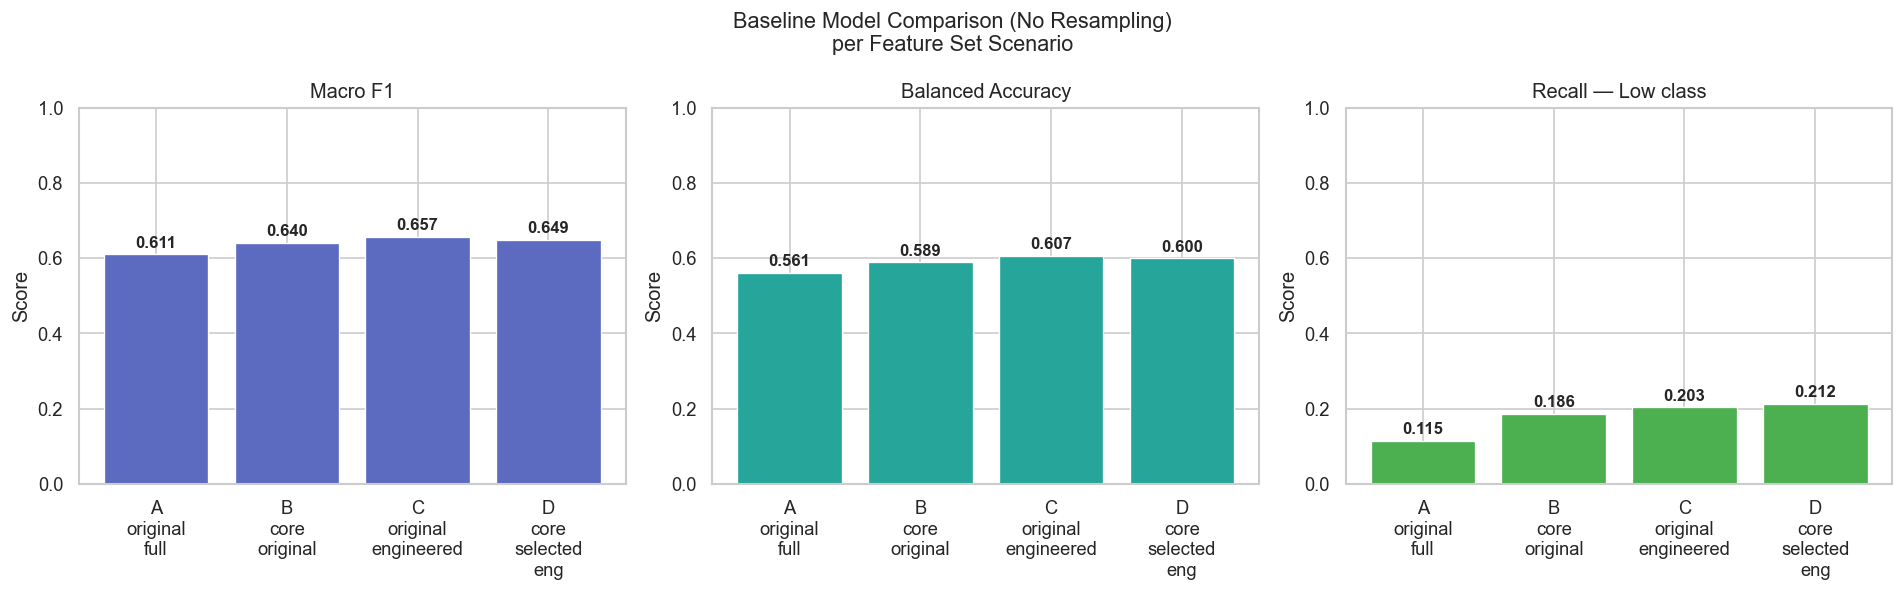

In [12]:
# Visualisasii
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Model Comparison (No Resampling)\nper Feature Set Scenario', fontsize=13)

metrics = [
    ('macro_f1',          'Macro F1',          '#5C6BC0'),
    ('balanced_accuracy', 'Balanced Accuracy',  '#26A69A'),
    ('recall_Low',        'Recall — Low class', '#4CAF50'),
]

scen_labels = [s.replace('_', '\n') for s in baseline_df['scenario']]

for ax, (metric, title, color) in zip(axes, metrics):
    bars = ax.bar(scen_labels, baseline_df[metric], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, baseline_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '04_baseline_comparison.png', bbox_inches='tight')
plt.show()

Scenario baseline terbaik (macro_f1): C_original_engineered
Scenario utama untuk resampling: D_core_selected_eng


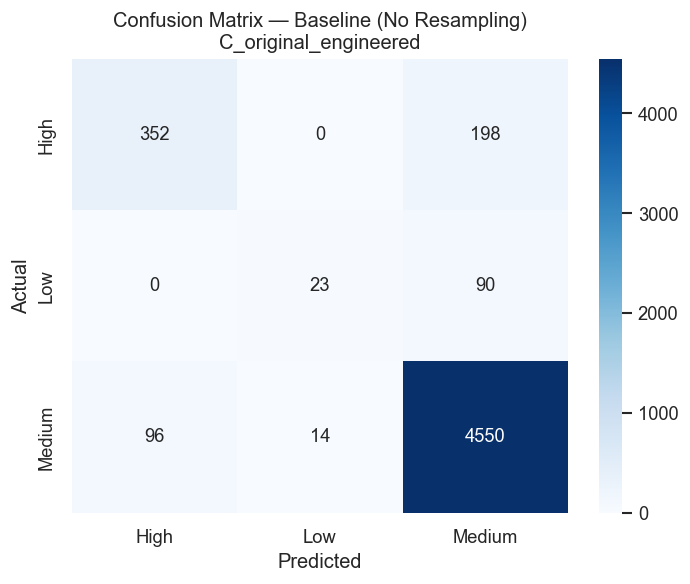

In [13]:
# Confusion matrix untuk scenario baseline terbaik berdasarkan macro_f1
best_baseline_scenario = baseline_df.loc[baseline_df['macro_f1'].idxmax(), 'scenario']
best_baseline_features  = scenarios[best_baseline_scenario]

# Scenario utama untuk tahap resampling ditentukan berdasarkan kombinasi:
# - class overlap yang lebih rendah
# - jumlah fitur yang lebih ringkas
# - pengurangan risiko feature redundancy pada feature space berbasis jarak
recommended_resampling_scenario = 'D_core_selected_eng'
recommended_resampling_features = scenarios[recommended_resampling_scenario]

print(f'Scenario baseline terbaik (macro_f1): {best_baseline_scenario}')
print(f'Scenario utama untuk resampling: {recommended_resampling_scenario}')

scaler = StandardScaler()
X_train_best = scaler.fit_transform(df_train[best_baseline_features].values)
X_test_best  = scaler.transform(df_test[best_baseline_features].values)
y_train_best = le.transform(df_train[TARGET])
y_test_best  = le.transform(df_test[TARGET])

clf_best = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_best.fit(X_train_best, y_train_best)
y_pred_best = clf_best.predict(X_test_best)

cm = confusion_matrix(y_test_best, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax
)
ax.set_title(f'Confusion Matrix — Baseline (No Resampling)\n{best_baseline_scenario}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '05_confusion_matrix_baseline.png', bbox_inches='tight')
plt.show()


# 08. feature set comparison summary 


In [14]:
feature_set_comparison = baseline_df[[
    'scenario', 'n_features', 'macro_f1', 'balanced_accuracy',
    'recall_Low', 'recall_High', 'accuracy'
]].copy()

feature_set_comparison['best_baseline_metric'] = (
    feature_set_comparison['scenario'] == best_baseline_scenario
)

feature_set_comparison['recommended_for_resampling'] = (
    feature_set_comparison['scenario'] == recommended_resampling_scenario
)

feature_set_comparison.to_csv(OUTPUT_REPORTS + 'feature_set_comparison.csv', index=False)
print('Saved: feature_set_comparison.csv')
print()
print(feature_set_comparison.to_string(index=False))


Saved: feature_set_comparison.csv

             scenario  n_features  macro_f1  balanced_accuracy  recall_Low  recall_High  accuracy  best_baseline_metric  recommended_for_resampling
      A_original_full          13    0.6106             0.5607      0.1150       0.5855    0.9222                 False                       False
      B_core_original           8    0.6403             0.5885      0.1858       0.6036    0.9207                 False                       False
C_original_engineered          19    0.6567             0.6066      0.2035       0.6400    0.9252                  True                       False
  D_core_selected_eng          13    0.6489             0.5999      0.2124       0.6145    0.9196                 False                        True


# 09.  Resampling Readiness Decision

In [15]:
resampling_mixing = overlap_df[
    overlap_df['scenario'] == recommended_resampling_scenario
].set_index('class')

low_mixing_ratio  = resampling_mixing.loc['Low', 'mixing_ratio']
high_mixing_ratio = resampling_mixing.loc['High', 'mixing_ratio']

low_recall_baseline  = baseline_df.loc[
    baseline_df['scenario'] == recommended_resampling_scenario,
    'recall_Low'
].values[0]

high_recall_baseline = baseline_df.loc[
    baseline_df['scenario'] == recommended_resampling_scenario,
    'recall_High'
].values[0]

best_baseline_macro_f1 = baseline_df.loc[
    baseline_df['scenario'] == best_baseline_scenario,
    'macro_f1'
].values[0]

recommended_macro_f1 = baseline_df.loc[
    baseline_df['scenario'] == recommended_resampling_scenario,
    'macro_f1'
].values[0]


def smote_recommendation(mixing_ratio):
    if mixing_ratio < 0.20:
        return 'SMOTE masuk akal - cek baseline dulu'
    elif mixing_ratio < 0.40:
        return 'Uji RandomOverSampler dan class_weight sebelum SMOTE'
    elif mixing_ratio < 0.60:
        return 'BorderlineSMOTE atau SMOTE-Tomek lebih aman'
    else:
        return 'SMOTE polos TIDAK direkomendasikan sebagai output utama'


decision_lines = [
    '# Resampling Readiness Decision',
    '',

    f'**Scenario baseline terbaik berdasarkan macro_f1:** `{best_baseline_scenario}` '
    f'(macro_f1={best_baseline_macro_f1:.4f})',
    f'**Feature set utama untuk resampling:** `{recommended_resampling_scenario}` '
    f'(macro_f1 baseline={recommended_macro_f1:.4f})',
    f'**Split strategy:** GroupShuffleSplit by user_id (mencegah user-level leakage)',

    '',
    '## Alasan Pemilihan Feature Set Resampling',
    '',
    '- Scenario baseline terbaik ditentukan berdasarkan macro_f1 pada model tanpa resampling.',
    '- Feature set utama untuk resampling ditentukan dengan mempertimbangkan class overlap, jumlah fitur, interpretabilitas, dan risiko feature redundancy.',
    '- Scenario D digunakan sebagai feature set utama resampling karena lebih ringkas dan memiliki overlap Low/High yang lebih rendah dibandingkan full engineered feature set.',

    '',
    '## Distribusi Kelas (Train Set)',

    f'- Low    : {df_train[TARGET].value_counts().get("Low",0)} samples '
    f'({df_train[TARGET].value_counts().get("Low",0)/len(df_train)*100:.1f}%)',

    f'- Medium : {df_train[TARGET].value_counts().get("Medium",0)} samples '
    f'({df_train[TARGET].value_counts().get("Medium",0)/len(df_train)*100:.1f}%)',

    f'- High   : {df_train[TARGET].value_counts().get("High",0)} samples '
    f'({df_train[TARGET].value_counts().get("High",0)/len(df_train)*100:.1f}%)',

    '',
    '## Class Overlap Status',

    f'- Low mixing ratio  : {low_mixing_ratio*100:.1f}% - '
    f'{interpret_mixing(low_mixing_ratio)}',

    f'- High mixing ratio : {high_mixing_ratio*100:.1f}% - '
    f'{interpret_mixing(high_mixing_ratio)}',

    '',
    '## Baseline Recall pada Feature Set Resampling (No Resampling)',

    f'- Recall Low  : {low_recall_baseline:.4f}',
    f'- Recall High : {high_recall_baseline:.4f}',

    '',
    '## Keputusan Resampling per Metode',

    '- No resampling     -> Baseline wajib (pembanding semua metode)',
    '- class_weight      -> Comparison only',
    '- RandomOverSampler -> Pembanding konservatif',

    f'- SMOTE             -> '
    f'{smote_recommendation(low_mixing_ratio)} '
    f'(berdasarkan Low class mixing)',

    '- BorderlineSMOTE   -> Candidate untuk boundary area',
    '- SMOTE-Tomek       -> Candidate kuat jika hasilnya paling stabil',

    '',
    '## Non-Negotiable',

    '- stress_score tidak masuk fitur (target leakage)',
    '- Resampling hanya pada train set',
    '- Test set tidak disentuh',
    '- Metric utama: macro_f1, balanced_accuracy, recall per class',
    '- Accuracy BUKAN metric utama',
]

decision_text = '\n'.join(decision_lines)

with open(OUTPUT_REPORTS + 'resampling_readiness_decision.md', 'w') as f:
    f.write(decision_text)

print(decision_text)
print()
print('Saved: resampling_readiness_decision.md')


# Resampling Readiness Decision

**Scenario baseline terbaik berdasarkan macro_f1:** `C_original_engineered` (macro_f1=0.6567)
**Feature set utama untuk resampling:** `D_core_selected_eng` (macro_f1 baseline=0.6489)
**Split strategy:** GroupShuffleSplit by user_id (mencegah user-level leakage)

## Alasan Pemilihan Feature Set Resampling

- Scenario baseline terbaik ditentukan berdasarkan macro_f1 pada model tanpa resampling.
- Feature set utama untuk resampling ditentukan dengan mempertimbangkan class overlap, jumlah fitur, interpretabilitas, dan risiko feature redundancy.
- Scenario D digunakan sebagai feature set utama resampling karena lebih ringkas dan memiliki overlap Low/High yang lebih rendah dibandingkan full engineered feature set.

## Distribusi Kelas (Train Set)
- Low    : 627 samples (2.9%)
- Medium : 18596 samples (87.5%)
- High   : 2033 samples (9.6%)

## Class Overlap Status
- Low mixing ratio  : 78.8% - Overlap berat — SMOTE polos TIDAK direkomendasikan
- High mixing ra

# 10. Summary

In [16]:
print('=== Summary Output Notebook 05 ===')
print()
print('Reports:')
print('  outputs/reports/split_strategy_summary.csv')
print('  outputs/reports/class_overlap_diagnostic_summary.csv')
print('  outputs/reports/feature_set_comparison.csv')
print('  outputs/reports/baseline_model_without_resampling.csv')
print('  outputs/reports/resampling_readiness_decision.md')
print()
print('Figures:')
print('  outputs/figures/resampling_diagnostics/01_multicollinearity_heatmap.png')
print('  outputs/figures/resampling_diagnostics/02_class_mixing_per_scenario.png')
print('  outputs/figures/resampling_diagnostics/03_pca_class_separability.png')
print('  outputs/figures/resampling_diagnostics/04_baseline_comparison.png')
print('  outputs/figures/resampling_diagnostics/05_confusion_matrix_baseline.png')
print()
print('Next step: 06_resampling_dataset_generation.ipynb')
print(f'  → Gunakan feature set: {recommended_resampling_scenario}')
print(f'  → Split: GroupShuffleSplit by user_id (train_idx / test_idx dari notebook ini)')
print(f'  → Low mixing ratio {low_mixing_ratio*100:.1f}% → {smote_recommendation(low_mixing_ratio)}')


=== Summary Output Notebook 05 ===

Reports:
  outputs/reports/split_strategy_summary.csv
  outputs/reports/class_overlap_diagnostic_summary.csv
  outputs/reports/feature_set_comparison.csv
  outputs/reports/baseline_model_without_resampling.csv
  outputs/reports/resampling_readiness_decision.md

Figures:
  outputs/figures/resampling_diagnostics/01_multicollinearity_heatmap.png
  outputs/figures/resampling_diagnostics/02_class_mixing_per_scenario.png
  outputs/figures/resampling_diagnostics/03_pca_class_separability.png
  outputs/figures/resampling_diagnostics/04_baseline_comparison.png
  outputs/figures/resampling_diagnostics/05_confusion_matrix_baseline.png

Next step: 06_resampling_dataset_generation.ipynb
  → Gunakan feature set: D_core_selected_eng
  → Split: GroupShuffleSplit by user_id (train_idx / test_idx dari notebook ini)
  → Low mixing ratio 78.8% → SMOTE polos TIDAK direkomendasikan sebagai output utama


## Insight

Hasil analisis menunjukkan bahwa target `stress_level` memiliki distribusi kelas yang tidak seimbang, dengan kelas `Medium` sebagai kelas dominan dan kelas `Low` sebagai kelas minoritas paling kecil. Kondisi ini berpotensi membuat model memiliki performa keseluruhan yang terlihat tinggi, tetapi kurang sensitif terhadap kelas minoritas.

Analisis overlap menunjukkan bahwa kelas `Low` memiliki tingkat pencampuran yang paling tinggi terhadap kelas lain pada seluruh skenario feature set. Hal ini menunjukkan bahwa pemisahan kelas `Low` dari `Medium` tidak cukup kuat hanya dengan feature space yang tersedia. Pada kondisi seperti ini, penggunaan SMOTE polos perlu diperlakukan secara hati-hati karena sample sintetis dapat terbentuk pada area yang masih ambigu.

Dari sisi baseline model, `C_original_engineered` menghasilkan nilai macro F1 tertinggi. Namun, untuk kebutuhan resampling, pemilihan feature set tidak hanya ditentukan oleh baseline metric. Scenario `D_core_selected_eng` lebih sesuai sebagai feature set utama resampling karena menggunakan fitur yang lebih ringkas, menghindari engineered feature yang memiliki indikasi redundancy, dan menghasilkan mixing ratio yang lebih rendah dibanding full engineered scenario.

* Distribusi `stress_level` pada data train masih tidak seimbang. Kelas Medium mendominasi, sedangkan Low dan High jumlahnya jauh lebih sedikit. Kondisi ini membuat model baseline cenderung bias ke kelas mayoritas.

* Analisis nearest-neighbor menunjukkan overlap kelas Low masih tinggi. Pada Scenario D, mixing ratio Low digunakan sebagai acuan utama resampling karena feature set ini lebih ringkas dan memiliki overlap yang lebih rendah dibandingkan full engineered feature set. Kondisi overlap yang tinggi membuat penggunaan SMOTE standar berisiko menghasilkan synthetic sample yang ambigu.

* Kelas High juga menunjukkan overlap yang cukup besar dengan Medium. Kondisi ini menandakan pemisahan antar kelas belum benar-benar jelas, sehingga proses resampling perlu dilakukan secara hati-hati dan tetap dibandingkan dengan baseline.

* Visualisasi PCA memperlihatkan bahwa distribusi Low dan Medium banyak bertumpang tindih pada dua komponen utama. Kelas High terlihat sedikit lebih terpisah, tetapi masih memiliki area transisi dengan Medium.

* Pemeriksaan multicollinearity menemukan bahwa `emotional_pressure_index` memiliki korelasi terlalu tinggi dengan fitur lain, sehingga dikeluarkan dari Scenario D. Lima engineered feature numerik lainnya tetap digunakan karena masih memberikan informasi tambahan yang relevan.

* Scenario C memiliki macro F1 baseline tertinggi pada model tanpa resampling. Namun, feature set utama untuk tahap resampling tetap menggunakan Scenario D karena pemilihan feature space resampling perlu mempertimbangkan overlap, jumlah fitur, interpretabilitas, dan risiko redundancy.

* Model baseline tanpa resampling masih memiliki recall yang rendah pada kelas Low. Hasil ini menunjukkan bahwa model kesulitan mengenali stres rendah secara konsisten jika dilatih langsung pada distribusi data asli.

* Proses pembagian data menggunakan `GroupShuffleSplit` berjalan sesuai rencana. Tidak ada user yang muncul di train dan test secara bersamaan. Perbedaan distribusi kelas antar split dianggap wajar karena pemisahan dilakukan berdasarkan user, bukan berdasarkan baris data.


## Conclusion

Analisis ini menunjukkan bahwa proses resampling tidak dapat langsung dilakukan hanya karena dataset mengalami class imbalance. Dataset juga memiliki indikasi class overlap, terutama pada kelas `Low`, sehingga metode oversampling berbasis interpolasi perlu diuji dengan pembanding yang lebih konservatif.

`C_original_engineered` dapat dicatat sebagai scenario dengan baseline macro F1 tertinggi. Namun, `D_core_selected_eng` digunakan sebagai feature set utama untuk tahap resampling karena lebih aman secara metodologis, lebih ringkas, dan memiliki overlap yang lebih rendah. Dengan demikian, pemilihan scenario untuk resampling mempertimbangkan kombinasi antara performa baseline, risiko overlap, dan risiko feature redundancy.

* Permasalahan utama pada dataset ini bukan hanya class imbalance, tetapi juga overlap antar kelas yang tinggi. Kelas Low memiliki mixing ratio yang tinggi, sehingga pemisahan dengan kelas lain, terutama Medium, menjadi sulit dan memengaruhi pemilihan metode resampling.

* Feature `emotional_pressure_index` terdeteksi sebagai near-duplicate karena memiliki korelasi tinggi dengan fitur lain. Fitur ini dikeluarkan dari proses modelling, tetapi masih dapat digunakan untuk kebutuhan visualisasi atau analisis insight.

* Scenario C dicatat sebagai scenario baseline dengan macro F1 tertinggi pada model tanpa resampling. Namun, feature set final yang digunakan untuk tahap resampling adalah Scenario D, yang terdiri dari 13 fitur: 8 fitur original dan 5 engineered feature terpilih.

* Pembagian data dilakukan menggunakan `GroupShuffleSplit` berbasis `user_id` dengan rasio 80:20. Pendekatan ini mencegah kebocoran data antar user dan membuat evaluasi model lebih representatif terhadap kondisi pengguna baru.

* Accuracy tidak digunakan sebagai metrik utama evaluasi. Meskipun baseline accuracy terlihat cukup tinggi, recall pada kelas Low masih rendah, sehingga evaluasi lebih difokuskan pada metric yang mempertimbangkan keseimbangan performa antar kelas, seperti macro F1 dan balanced accuracy.


## Recomendation

1. Gunakan `D_core_selected_eng` sebagai feature set utama untuk eksperimen resampling pada notebook berikutnya.
2. Simpan `C_original_engineered` sebagai pembanding full engineered scenario, bukan sebagai satu-satunya dasar keputusan resampling.
3. Hindari penggunaan `stress_score` sebagai fitur modelling karena target modelling adalah `stress_level`.
4. Pertahankan split berbasis `user_id` agar evaluasi tidak terkena user-level leakage.
5. Perlakukan SMOTE polos sebagai metode experimental karena kelas minoritas masih memiliki overlap tinggi.
6. Bandingkan hasil resampling menggunakan macro F1, balanced accuracy, recall per class, dan confusion matrix, bukan hanya accuracy.

* Gunakan Scenario D sebagai feature set utama untuk proses resampling. Scenario ini dipilih karena lebih ringkas, mengurangi risiko redundancy, dan memiliki overlap Low/High yang lebih rendah dibandingkan full engineered feature set.

* Scenario C tetap dicatat sebagai pembanding baseline/full engineered karena memiliki macro F1 baseline tertinggi pada model tanpa resampling. Namun, Scenario C tidak digunakan sebagai feature set utama resampling karena penggunaan seluruh engineered feature dapat meningkatkan risiko noise dan redundancy pada feature space berbasis jarak.

* SMOTE standar tidak disarankan sebagai output utama ketika overlap kelas Low masih tinggi. Pembuatan synthetic sample pada area yang ambigu dapat memperbesar noise pada data.

* BorderlineSMOTE dan SMOTE-Tomek lebih layak diprioritaskan pada tahap eksperimen resampling. Kedua metode ini lebih selektif dalam menangani area boundary dan lebih sesuai untuk kondisi overlap yang tinggi.

* Reproduksi split pada notebook 06 perlu menggunakan `GroupShuffleSplit` dengan `random_state=42` yang sama seperti notebook 05. Konsistensi split penting agar evaluasi antar eksperimen tetap fair dan tidak bias.

* Perbedaan distribusi kelas antara train dan test perlu dicatat secara eksplisit dalam changelog handoff. Kondisi ini bukan kesalahan preprocessing, melainkan konsekuensi yang memang diharapkan dari pendekatan split berbasis user.

* Penghapusan `emotional_pressure_index` dari feature set modelling juga perlu dijelaskan dalam changelog. Dokumentasi ini penting agar Tim AI Engineer memahami alasan fitur tersebut tidak muncul pada dataset final yang digunakan untuk eksperimen resampling.
